# Example: Let's Fit a Logistic Regression Classifier with Gradient Descent and Simulated Annealing
How do gradient descent and simulated annealing compare when they minimize the same loss? We'll use two overlapping clusters of synthetic data to connect the logistic regression model and the two optimization methods from [the lecture](CHEME-5800-L9c-Lecture-LogisticRegressionAndOptimization-Fall-2026.ipynb) to a numerical calculation.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Fit a logistic regression model with gradient descent:** Gradient descent estimates the model parameters by repeatedly stepping against the gradient of the cross-entropy loss. We'll implement the update with the gradient from the lecture, choose the learning rate from the training data, and watch the loss fall.
> * **Classify points with the model's probabilities:** The model gives each point a probability of belonging to the positive class, and a threshold turns that probability into a label. We'll draw the probability contours and the decision boundary, and see how the threshold trades missed positives for false alarms on the testing data.
> * **Fit the same model with simulated annealing:** Simulated annealing minimizes the loss using only loss values, and it accepts some uphill moves with a probability that falls as the temperature decreases. We'll choose the initial temperature with the sample-and-set rule and compare the result with gradient descent.

In this example, we fit one logistic regression model to two overlapping clusters of points with both optimization methods, and compare the parameters, the work each method needs, and the labels the model assigns. Let's get started!
___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course package and the packages used here.

Let's set up our code environment:

In [1]:
# Load packages and paths -
include(joinpath(@__DIR__, "Include.jl")); # @__DIR__ locates this notebook's setup file

# Choose the plot appearance -
# After changing the theme, rerun this cell and the plotting cells.
theme(:default)   # light background
# theme(:dark)   # dark background

In addition to the Julia standard libraries, we use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). See [the course package documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/), the [Julia documentation](https://docs.julialang.org/en/v1/), the [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/), and the [Plots.jl documentation](https://docs.juliaplots.org/stable/) for the functions and types used here.

### Data
We generate a synthetic dataset with two classes, each a cloud of points in the plane. The positive class ($y=+1$) is centered at $(1,1)$ and the negative class ($y=-1$) at $(-1,-1)$, and each point is its center plus normal noise with a standard deviation of one in each feature. The two clouds overlap, and no straight line separates the points we generate here, so the cross-entropy loss has a minimizer.

Let's generate 150 points per class. We store the features in the `X::Matrix{Float64}` variable, one row per point, and the labels in the `y::Vector{Float64}` variable:

In [2]:
X, y = let

    # initialize -
    seed = 5800; # seed for the random number generator; change it to get a different dataset
    rng = MersenneTwister(seed); # random number generator used only for the data
    number_per_class = 150; # number of points in each class
    noise = 1.0; # standard deviation of the noise around each center

    # generate the two clouds -
    X₊ = [1.0 1.0] .+ noise*randn(rng, number_per_class, 2); # positive class, centered at (1, 1)
    X₋ = [-1.0 -1.0] .+ noise*randn(rng, number_per_class, 2); # negative class, centered at (-1, -1)

    # stack the classes -
    X = [X₊; X₋]; # features: the positive class first, then the negative class
    y = [ones(number_per_class); -ones(number_per_class)]; # labels in the same order

    X, y; # return
end;

Finally, let's partition the data into a `training` set and a `testing` set, so that we can measure how well the classifier labels points it has not seen. We select the training points at random with a seeded random number generator, so the split is the same every time we run the notebook.

We also append a column of ones to each data matrix, which gives the augmented features $\hat{\mathbf{x}}$ from the lecture, whose last entry multiplies the bias $b$. Each set is a `NamedTuple` with the fields `X` (the augmented data matrix) and `y` (the labels):

In [3]:
training, testing = let

    # initialize -
    s = 0.80; # fraction of data for training
    seed = 1234; # seed for the random number generator; change it to get a different split
    rng = MersenneTwister(seed); # random number generator used only for this split
    number_of_samples = size(X,1); # number of points in the dataset
    number_of_training_samples = floor(Int, s*number_of_samples); # 80% of the data for training
    i = randperm(rng, number_of_samples); # random permutation of the row indices
    training_indices = i[1:number_of_training_samples]; # first 80% of the shuffled indices
    testing_indices = i[number_of_training_samples+1:end]; # last 20% of the shuffled indices

    # setup training -
    one_vector = ones(number_of_training_samples); # column of ones for the bias
    training = (X=[X[training_indices, :] one_vector], y=y[training_indices]);

    # setup testing -
    one_vector = ones(length(testing_indices)); # column of ones for the bias
    testing = (X=[X[testing_indices, :] one_vector], y=y[testing_indices]);

    # print the size of each set -
    println("training: ", length(training.y), " points, testing: ", length(testing.y), " points")

    training, testing; # return
end;

training: 240 points, testing: 60 points


___

## Task 1: Fit the model with gradient descent
In this task, we estimate the parameters $\mathbf{\theta}=(w_{1},w_{2},b)$ by minimizing the cross-entropy loss with gradient descent. From the lecture, the loss and its gradient are given by:
$$
\begin{align*}
J(\mathbf{\theta}) & = \sum_{i=1}^n \log\!\bigl(1+e^{-u_{i}}\bigr)\\
\nabla J(\mathbf{\theta}) & = -2\beta\sum_{i=1}^{n}\bigl(1-\sigma(u_{i})\bigr)\,y_{i}\,\hat{\mathbf{x}}_{i}
\end{align*}
$$
where the sums run over the $n$ training points, $u_{i} = 2\beta y_{i}\,\hat{\mathbf{x}}_{i}^{\top}\mathbf{\theta}$, and $\sigma(z)=1/(1+e^{-z})$ is the logistic function.

We use the constant learning rate $\alpha = 1/L$, so every step lowers the loss. Here, $L=\beta^{2}\lVert\hat{\mathbf{X}}\rVert_{2}^{2}$ is the Lipschitz constant of the gradient, and $\lVert\hat{\mathbf{X}}\rVert_{2}$ is the largest singular value of the augmented training data matrix $\hat{\mathbf{X}}$ (the `training.X` array).

Let's set the inverse temperature, compute the learning rate from the training data matrix, and define the cross-entropy loss $J(\mathbf{\theta})$ as a one-line function, which we use again in Task 3:

In [4]:
β = 1.0; # inverse temperature: we fix it and learn θ
L = β^2*opnorm(training.X)^2; # Lipschitz constant of the gradient: β² times the largest singular value squared
α = 1/L; # learning rate: the largest constant step that the lecture's bound allows
J(θ) = sum(log(1 + exp(-2β*training.y[i]*dot(training.X[i,:], θ))) for i ∈ eachindex(training.y)); # cross-entropy loss on the training data
println("L = ", round(L, digits=2), ", learning rate α = ", round(α, sigdigits=4))

L = 717.06

, learning rate α = 0.001395


Now let's run gradient descent from $\mathbf{\theta}^{(0)}=\mathbf{0}$. The loop follows the lecture's algorithm: compute the gradient, take a step, and stop when the parameters change by less than $\epsilon$ or after $\texttt{maxiter}$ iterations. We save the estimated parameters in the `θ̂_gd::Vector{Float64}` variable and the loss after every iteration in the `losses_gd::Vector{Float64}` variable:

In [5]:
θ̂_gd, losses_gd = let

    # initialize -
    X = training.X; # augmented training data matrix
    y = training.y; # training labels
    θ = zeros(size(X,2)); # initial guess θ⁽⁰⁾ = 0
    ϵ = 1e-6; # stopping tolerance on the change in θ
    maxiter = 10_000; # maximum number of iterations
    losses = [J(θ)]; # loss at each iteration, starting from θ⁽⁰⁾
    converged = false; # did the change in θ fall below ϵ?

    # main loop -
    for k ∈ 1:maxiter

        # gradient of the cross-entropy loss -
        ∇J = zeros(length(θ));
        for i ∈ eachindex(y)
            uᵢ = 2β*y[i]*dot(X[i,:], θ); # uᵢ = 2β yᵢ x̂ᵢᵀθ
            ∇J += -2β*(1 - 1/(1 + exp(-uᵢ)))*y[i]*X[i,:]; # term i: weighted by the probability of the wrong label
        end

        # update the parameters -
        θ_new = θ - α*∇J; # step against the gradient
        push!(losses, J(θ_new));

        # check the stopping criterion -
        if norm(θ_new - θ) ≤ ϵ
            println("converged after ", k, " iterations");
            θ = θ_new;
            converged = true;
            break # this means: leave the loop now
        end
        θ = θ_new; # not done yet, so keep going from the new parameters
    end
    if converged == false
        println("reached maxiter = ", maxiter, " without convergence");
    end

    θ, losses; # return
end;

converged after 392

 iterations


Let's look at the estimated parameters and the final loss:

In [6]:
let

    # build the table -
    df = DataFrame(
        parameter = ["w₁", "w₂", "b (bias)", "J(θ̂)"], # one label per row
        value = round.([θ̂_gd; J(θ̂_gd)], digits=4) # estimated parameters, then the loss
    );

    # show the table -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = [:l, :r] # left-align text and right-align numerical columns
    );
end

┌───────────┬─────────┐
│ parameter │   value │
├───────────┼─────────┤
│ w₁        │  1.0487 │
│ w₂        │  1.2242 │
│ b (bias)  │ -0.1999 │
│ J(θ̂)      │ 40.1929 │
└───────────┴─────────┘


The two weights are similar in size because the two cluster centers differ by the same amount in each feature. The bias is small, so the decision boundary passes close to the origin, the midpoint between the two centers.

How did the loss change as gradient descent ran? Let's plot the loss after each iteration:

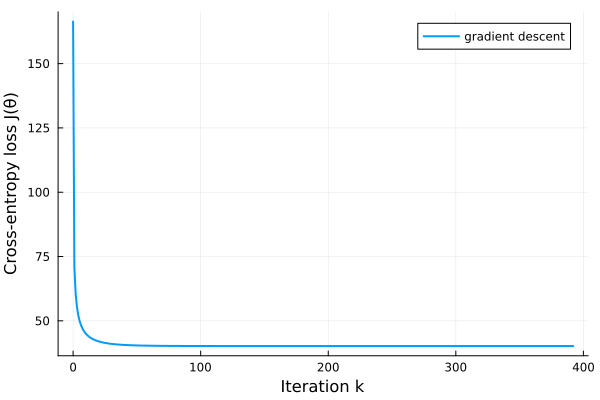

In [7]:
let
    plot(0:length(losses_gd)-1, losses_gd, lw=2, label="gradient descent",
        xlabel="Iteration k", ylabel="Cross-entropy loss J(θ)")
end

__What do we see?__ The loss falls steeply in the first few iterations and then levels off, which is the "sprint at first, then a steady jog" behavior from the lecture. Every step lowered the loss, as the learning rate $\alpha=1/L$ guarantees. Your numbers may differ if you change the seed, the noise, or the stopping tolerance.

___

## Task 2: Classify points with the model's probabilities
In this task, we use the fitted model to compute the probability that each point belongs to the positive class, $P_{\hat{\mathbf{\theta}}}(y=+1\mid\hat{\mathbf{x}})=\sigma(2\beta\,\hat{\mathbf{x}}^{\top}\hat{\mathbf{\theta}})$. First, let's draw this probability over the plane with the training points on top. The $1/2$ contour is the decision boundary:

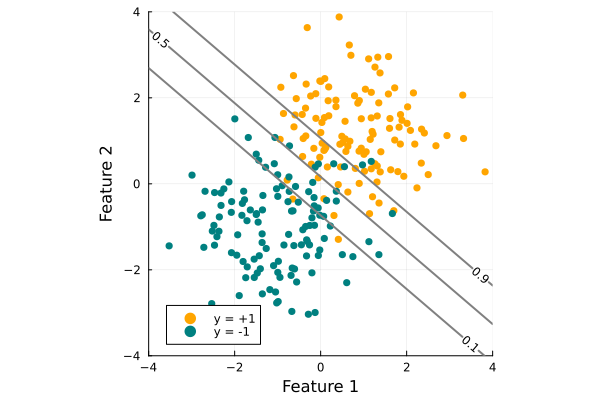

In [8]:
let

    # initialize -
    θ = θ̂_gd; # estimated parameters (w₁, w₂, b)
    x₁ = range(-4, 4, length=201); # grid for feature 1
    x₂ = range(-4, 4, length=201); # grid for feature 2
    P(a, b) = 1/(1 + exp(-2β*(θ[1]*a + θ[2]*b + θ[3]))); # probability of y = +1 at the point (a, b)
    positive = findall(training.y .== 1); # rows of the positive training points
    negative = findall(training.y .== -1); # rows of the negative training points

    # training points -
    scatter(training.X[positive,1], training.X[positive,2], label="y = +1", ms=4, msw=0, c=:orange)
    scatter!(training.X[negative,1], training.X[negative,2], label="y = -1", ms=4, msw=0, c=:teal)

    # probability contours -
    contour!(x₁, x₂, P, levels=[0.1, 0.5, 0.9], lw=2, c=:gray, clabels=true, cbar=false)
    plot!(xlims=(-4,4), ylims=(-4,4), aspect_ratio=:equal, xlabel="Feature 1", ylabel="Feature 2", legend=:bottomleft)
end

__What do we see?__ The contours are parallel straight lines, because the probability depends on a point only through its score $\hat{\mathbf{x}}^{\top}\hat{\mathbf{\theta}}$, which is linear in the features. The model is least certain about the points near the boundary, between the $0.1$ and $0.9$ contours. A few points sit on the wrong side of the boundary with a confident probability: the clouds overlap, and no line classifies every training point correctly.

Next, let's classify the testing points at several thresholds $t$. For each threshold, we predict $\hat{y}=+1$ when the probability is at least $t$, compute the confusion matrix with [the `confusion(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/binaryclassification/#VLDataScienceMachineLearningPackage.confusion), and record the counts, the recall (the fraction of actual positives the classifier finds), and the precision (the fraction of positive predictions that are correct):

In [9]:
let

    # initialize -
    X = testing.X; # augmented testing data matrix
    y = testing.y; # actual testing labels
    thresholds = [0.1, 0.25, 0.5, 0.75, 0.9]; # thresholds t to compare
    P = [1/(1 + exp(-2β*dot(X[i,:], θ̂_gd))) for i ∈ eachindex(y)]; # probability of y = +1 for each testing point
    df = DataFrame(); # hold the data (rows) for the table

    # build the rows of the table -
    for t ∈ thresholds
        ŷ = [p ≥ t ? 1 : -1 for p ∈ P]; # estimated labels at threshold t
        CM = confusion(y, ŷ); # important: actual labels first, estimated labels second
        TP = CM[1,1]; # positive points labeled positive
        FN = CM[1,2]; # positive points labeled negative (missed positives)
        FP = CM[2,1]; # negative points labeled positive (false alarms)
        TN = CM[2,2]; # negative points labeled negative
        push!(df, (t = t, TP = TP, FN = FN, FP = FP, TN = TN,
            recall = round(TP/(TP + FN), digits=3), precision = round(TP/(TP + FP), digits=3)));
    end

    # show the table -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = :r # right-align numerical columns
    );
end

┌──────┬────┬────┬────┬────┬────────┬───────────┐
│    t │ TP │ FN │ FP │ TN │ recall │ precision │
├──────┼────┼────┼────┼────┼────────┼───────────┤
│  0.1 │ 31 │  2 │  8 │ 19 │  0.939 │     0.795 │
│ 0.25 │ 30 │  3 │  5 │ 22 │  0.909 │     0.857 │
│  0.5 │ 30 │  3 │  2 │ 25 │  0.909 │     0.938 │
│ 0.75 │ 30 │  3 │  0 │ 27 │  0.909 │       1.0 │
│  0.9 │ 29 │  4 │  0 │ 27 │  0.879 │       1.0 │
└──────┴────┴────┴────┴────┴────────┴───────────┘


__What do we see?__ As the threshold falls, the model labels more testing points positive: the number of missed positives (FN) can only fall or stay the same, and the number of false alarms (FP) can only rise or stay the same. The row $t=1/2$ uses the decision boundary from the plot.

Here, lowering the threshold from $1/2$ to $0.1$ finds one more positive and adds six false alarms; your counts may differ if you change the seeds. Which threshold to use depends on what a missed positive costs compared with a false alarm.

___

## Task 3: Fit the same model with simulated annealing
In this task, we minimize the same cross-entropy loss with simulated annealing, which uses only loss values and never the gradient. The parameters have no constraints here, so the augmented objective from the lecture is the loss itself, and there are no penalty or barrier terms.

Let's set the parameters of the algorithm:

In [10]:
η = 0.1; # step size: each candidate adds η times a standard normal number to every parameter
M = 100; # number of random candidates used to choose the initial temperature
p₀ = 0.8; # desired initial acceptance rate for an average uphill move
c = 20; # iterations per parameter at each temperature, so K = c⋅n to start, with n = 3 parameters here
cooling_rate = 0.9; # the cooling rate α in the lecture (α is already the learning rate here)
T_min_fraction = 1e-4; # stop once the temperature falls below this fraction of T₀

First, we choose the initial temperature $T_{\circ}$ with the lecture's sample-and-set rule. From $\mathbf{\theta}=\mathbf{0}$, we generate $M$ random candidates, average the changes in the loss for the uphill ones, and set $T_{\circ}=-\overline{\Delta P}_{+}/\ln p_{\circ}$, so that an average uphill move is accepted with probability $p_{\circ}$ at the start. We save the result in the `T₀::Float64` variable:

In [11]:
T₀ = let

    # initialize -
    rng = MersenneTwister(1); # random number generator used only for this sample
    θ₀ = zeros(size(training.X,2)); # starting point θ = 0
    uphill = Float64[]; # changes in the loss for the uphill candidates

    # sample candidates; if none is uphill, generate more (as in the lecture) -
    while isempty(uphill)
        ΔP = [J(θ₀ + η*randn(rng, length(θ₀))) - J(θ₀) for _ ∈ 1:M]; # change in the loss for M random candidates
        uphill = filter(Δ -> Δ > 0, ΔP); # keep the candidates that raise the loss
    end

    # average the uphill changes -
    ΔP̄₊ = mean(uphill); # mean uphill change

    # print the result -
    T₀ = -ΔP̄₊/log(p₀); # an average uphill move is accepted with probability p₀
    println(length(uphill), " of ", M, " candidates are uphill; T₀ = ", round(T₀, digits=2))

    T₀; # return
end;

48 of 100 candidates are uphill; T₀ = 165.81


Now let's run simulated annealing from $\mathbf{\theta}=\mathbf{0}$. At each temperature, we try $K$ random candidates, accept every move that lowers the loss and an uphill move with probability $\exp(-\Delta P/T)$, and keep track of the best parameters found so far. After each temperature, we adapt $K$ with the lecture's acceptance-rate heuristic and cool the system.

We save the best parameters in the `θ̂_sa::Vector{Float64}` variable and the best loss after each temperature in the `best_losses_sa::Vector{Float64}` variable:

In [12]:
θ̂_sa, best_losses_sa = let

    # initialize -
    rng = MersenneTwister(5800); # random number generator used only for the annealing moves
    n = size(training.X,2); # number of parameters
    x_c = zeros(n); # current solution
    P_c = J(x_c); # loss at the current solution
    x_best = copy(x_c); # best solution found so far (x⋆ in the lecture)
    P_best = P_c; # loss at the best solution
    T = T₀; # current temperature
    T_min = T_min_fraction*T₀; # minimum temperature
    K = ceil(Int, c*n); # number of iterations at this temperature
    best_losses = [P_best]; # best loss after each temperature
    converged = false; # has the temperature schedule finished?
    evaluations = 1; # number of loss evaluations so far

    # main loop -
    while converged == false

        accepted = 0; # number of accepted moves at this temperature
        for k ∈ 1:K

            # generate a candidate and compute the change in the loss -
            x′ = x_c + η*randn(rng, n); # random move from the current solution
            ΔP = J(x′) - P_c; # change in the loss
            evaluations += 1;

            # accept an improving move, or an uphill move with probability exp(-ΔP/T) -
            if ΔP < 0 || rand(rng) ≤ exp(-ΔP/T) # Hmmmm. Tricky, why does this work?
                x_c = x′;
                P_c = P_c + ΔP;
                accepted += 1;
            end

            # update the best solution -
            if P_c < P_best
                x_best = copy(x_c);
                P_best = P_c;
            end
        end
        push!(best_losses, P_best);

        # adapt the number of iterations per temperature -
        p̂ = accepted/K; # acceptance rate at this temperature
        if p̂ > 0.8
            K = ceil(Int, 0.75*K); # accepting a lot: fewer iterations
        elseif p̂ < 0.2
            K = ceil(Int, 1.5*K); # accepting few moves: more iterations
        end

        # check the stopping condition -
        if T ≤ T_min
            converged = true; # the temperature schedule is complete
        else
            T = cooling_rate*T; # not done yet, so cool the system
        end
    end
    println("temperatures used: ", length(best_losses) - 1, ", loss evaluations: ", evaluations)

    x_best, best_losses; # return
end;

temperatures used: 89

, loss evaluations: 82478


How do the two answers compare? Let's put the parameters and the losses side by side:

In [13]:
let

    # build the table -
    df = DataFrame(
        quantity = ["w₁", "w₂", "b (bias)", "J(θ̂)"], # one label per row
        gradient_descent = round.([θ̂_gd; J(θ̂_gd)], digits=4), # Task 1
        simulated_annealing = round.([θ̂_sa; J(θ̂_sa)], digits=4) # Task 3
    );

    # show the table -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = [:l, :r, :r] # left-align text and right-align numerical columns
    );
end

┌──────────┬──────────────────┬─────────────────────┐
│ quantity │ gradient_descent │ simulated_annealing │
├──────────┼──────────────────┼─────────────────────┤
│ w₁       │           1.0487 │              1.0494 │
│ w₂       │           1.2242 │              1.2267 │
│ b (bias) │          -0.1999 │             -0.1982 │
│ J(θ̂)     │          40.1929 │             40.1931 │
└──────────┴──────────────────┴─────────────────────┘


The two methods agree closely: each parameter differs by less than $0.003$, and the losses differ by about $0.0002$. Let's also plot the best loss after each temperature, with the gradient descent loss as a reference line:

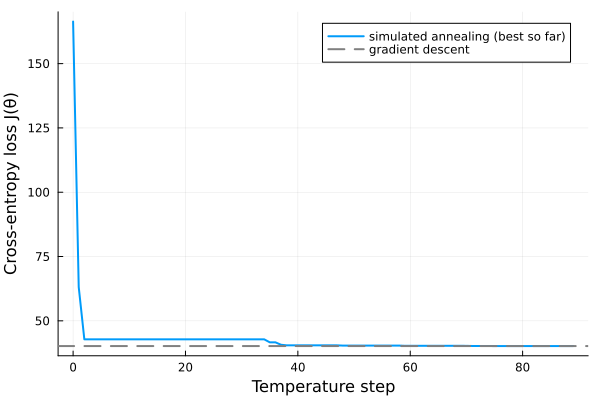

In [14]:
let
    plot(0:length(best_losses_sa)-1, best_losses_sa, lw=2, label="simulated annealing (best so far)",
        xlabel="Temperature step", ylabel="Cross-entropy loss J(θ)")
    hline!([J(θ̂_gd)], lw=2, ls=:dash, c=:gray, label="gradient descent")
end

__What do we see?__ The best loss drops sharply in the first two temperature steps and then stays flat for about thirty more. At these high temperatures, nearly every candidate is accepted, so the acceptance-rate heuristic shrinks $K$ to a few candidates per temperature, and the search rarely improves on its best point. Once the temperature is low enough that uphill moves become rare, the search settles near the gradient descent answer.

Without the gradient, a random candidate does not know which way is downhill, so near the minimum most candidates raise the loss and are rejected. The heuristic then keeps raising $K$ by half at each temperature, and almost all of the more than eighty thousand loss evaluations in the annealing loop come in the last ten temperatures.

Gradient descent needed a few hundred steps, each computing one gradient and one loss. Your numbers may differ if you change the seeds, the step size, or the cooling rate.

Do these small differences in the parameters change how the model classifies points? Let's draw the probability contours of the simulated annealing model over the training points, as we did for gradient descent in Task 2, and add the gradient descent decision boundary as a dashed line. We also count the testing points that the two models label differently at the threshold $t=1/2$:

testing points labeled differently: 0 of 60


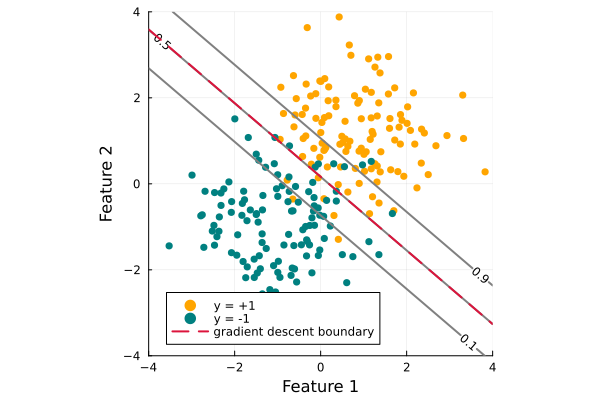

In [15]:
let

    # initialize -
    θ = θ̂_sa; # simulated annealing parameters (w₁, w₂, b)
    x₁ = range(-4, 4, length=201); # grid for feature 1
    x₂ = range(-4, 4, length=201); # grid for feature 2
    P(a, b) = 1/(1 + exp(-2β*(θ[1]*a + θ[2]*b + θ[3]))); # probability of y = +1 at the point (a, b)
    boundary_gd = [-(θ̂_gd[1]*a + θ̂_gd[3])/θ̂_gd[2] for a ∈ x₁]; # gradient descent boundary: w₁x₁ + w₂x₂ + b = 0
    positive = findall(training.y .== 1); # rows of the positive training points
    negative = findall(training.y .== -1); # rows of the negative training points

    # testing points labeled differently by the two models -
    ŷ_gd = [dot(testing.X[i,:], θ̂_gd) ≥ 0 ? 1 : -1 for i ∈ eachindex(testing.y)]; # P ≥ 1/2 exactly when the score is ≥ 0
    ŷ_sa = [dot(testing.X[i,:], θ̂_sa) ≥ 0 ? 1 : -1 for i ∈ eachindex(testing.y)];
    println("testing points labeled differently: ", count(ŷ_gd .!= ŷ_sa), " of ", length(testing.y))

    # training points -
    scatter(training.X[positive,1], training.X[positive,2], label="y = +1", ms=4, msw=0, c=:orange)
    scatter!(training.X[negative,1], training.X[negative,2], label="y = -1", ms=4, msw=0, c=:teal)

    # simulated annealing probability contours and the gradient descent boundary -
    contour!(x₁, x₂, P, levels=[0.1, 0.5, 0.9], lw=2, c=:gray, clabels=true, cbar=false)
    plot!(x₁, boundary_gd, lw=2, ls=:dash, c=:crimson, label="gradient descent boundary")
    plot!(xlims=(-4,4), ylims=(-4,4), aspect_ratio=:equal, xlabel="Feature 1", ylabel="Feature 2", legend=:bottomleft)
end

__What do we see?__ The dashed gradient descent boundary lies on top of the $1/2$ contour of the simulated annealing model, and the two models label every testing point the same way. For classifying these points, the small parameter differences do not matter.

### Check: Gradient descent and simulated annealing
Let's check that gradient descent stopped where the gradient is nearly zero and that every step lowered the loss, as the learning rate $\alpha=1/L$ guarantees.

The loss is convex, so a point where the gradient is zero is a global minimum. The gradient at the gradient descent answer is nearly zero, so we use its loss as the reference: simulated annealing should not find a loss lower than it by more than a small tolerance, and its loss should be within $0.1$ percent of it.

In [16]:
let

    # initialize -
    X = training.X; # augmented training data matrix
    y = training.y; # training labels
    tolerance = 1e-6; # absolute tolerance for comparing losses

    # gradient of the loss at the gradient descent answer -
    ∇J = zeros(length(θ̂_gd));
    for i ∈ eachindex(y)
        uᵢ = 2β*y[i]*dot(X[i,:], θ̂_gd); # uᵢ = 2β yᵢ x̂ᵢᵀθ
        ∇J += -2β*(1 - 1/(1 + exp(-uᵢ)))*y[i]*X[i,:]; # term i of the gradient
    end

    # checks -
    @testset "Gradient descent and simulated annealing checks" begin
        @test norm(∇J) < 1e-2 # the gradient is nearly zero at the answer
        @test all(diff(losses_gd) .≤ 0) # every gradient descent step lowered the loss
        @test J(θ̂_sa) ≥ J(θ̂_gd) - tolerance # no loss is below the minimum, which gradient descent has nearly reached
        @test J(θ̂_sa) ≤ 1.001*J(θ̂_gd) # simulated annealing is within 0.1 percent
    end
end;

Test Summary:                                   | Pass  

Total  Time
Gradient descent and simulated annealing checks |    4      4  0.3s


___

## Summary
In this example, we fit a logistic regression model to two overlapping clusters with gradient descent, used its probabilities to classify testing points at several thresholds, and fit the same model with simulated annealing.

> __Key Takeaways:__
>
> * **Gradient descent fits the model:** We implemented gradient descent with the gradient of the cross-entropy loss from the lecture and a learning rate computed from the training data. We saw the loss fall at every step, steeply at first and then slowly, until the parameters stopped changing.
> * **The threshold sets the trade-off:** We drew the probability contours, which are parallel straight lines, and classified the testing points at five thresholds. We saw that lowering the threshold can find more positives but also raises more false alarms, so the choice depends on what each mistake costs.
> * **Simulated annealing reaches nearly the same answer without the gradient:** We chose the initial temperature with the sample-and-set rule and minimized the same loss using only loss values. We found parameters close to the gradient descent answer, at the cost of many more loss evaluations, almost all of them at the lowest temperatures.

We can now change the overlap of the clusters, the thresholds, or the cooling rate and see how the fitted model and the two optimization methods respond.

___